Name- Sourav Patra

Roll No.- 3023149

EXTC B3

12/03/2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

iris = load_iris()
X=pd.DataFrame(iris.data, columns=iris.feature_names)
y=iris.target
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)
print(X.head())

Feature Shape: (150, 4)
Target Shape: (150,)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (105, 4)
X_test Shape: (45, 4)
y_train Shape: (105,)
y_test Shape: (45,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (105, 4)
Shape of X_test_scaled: (45, 4)


In [ ]:
from sklearn.model_selection import cross_val_score
k_range = range(1,21)
cv_scores =[]
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    #5-fold cross validation
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

#Find Best K
best_k = k_range[np.argmax(cv_scores)]
print("Best K using cross val:", best_k)

Best K using cross val: 14


<function matplotlib.pyplot.show(close=None, block=None)>

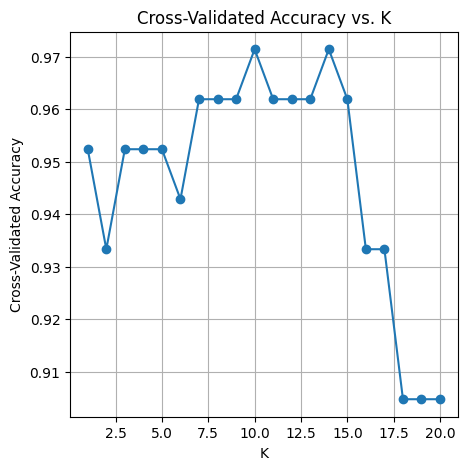

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Cross-Validated Accuracy vs. K')
plt.grid()
plt.show

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors = best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy of KNN:", knn_accuracy)

Accuracy of KNN: 0.9555555555555556


<Figure size 300x300 with 0 Axes>

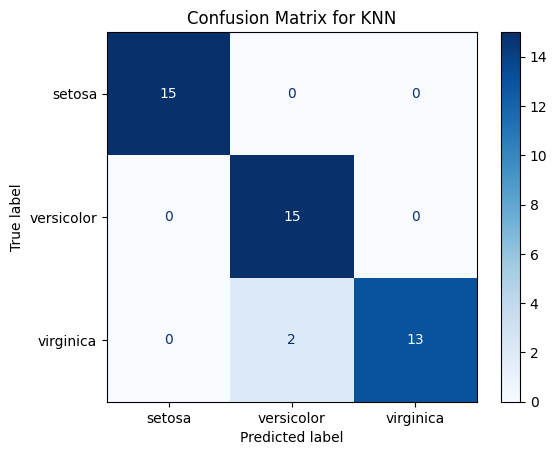

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(3,3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for KNN')
plt.show()

In [ ]:
new_sample = [[5.0, 2.9, 7.5, 1.5]]
new_sample_scaled = scaler.transform(new_sample)
prediction = knn_final.predict(new_sample_scaled)
print("Predicted Class:", iris.target_names[prediction[0]])

Predicted Class: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
